# TASK 3 - Car Price Prediction

## Problem Statement
**The price of a car depends on a lot of factors like the goodwill of the brand of the car, features of the car, horsepower and the mileage it gives and many more. Car price prediction is one of the major research areas in machine learning. So if you want to learn how to train a car price prediction model then this project is for you.**

**STEPS**
- Load dataset
- Clean and preprocess data
- Perform exploratory data analysis (EDA)
- Handle categorical features (encoding)
- Analyze feature relationships (correlation)
- Select important features
- Split data into training and testing sets
- Apply feature scaling
- Train regression model (Linear Regression / Random Forest)
- Evaluate model performance (R², MAE, MSE)
- Visualize predictions (Actual vs Predicted prices)

## Import Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Load Dataset

In [58]:
df = pd.read_csv("CarPrice.csv")
print(df.head())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

## Data Exploration

In [59]:
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-nul

## Missing Values

In [60]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


## Data Cleaning

In [61]:
df.drop(['car_ID'], axis=1, inplace=True)
df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0])
df.drop(['CarName'], axis=1, inplace=True)
print(df.head())
print(df.columns)

   symboling fueltype aspiration doornumber      carbody drivewheel  \
0          3      gas        std        two  convertible        rwd   
1          3      gas        std        two  convertible        rwd   
2          1      gas        std        two    hatchback        rwd   
3          2      gas        std       four        sedan        fwd   
4          2      gas        std       four        sedan        4wd   

  enginelocation  wheelbase  carlength  carwidth  ...  fuelsystem  boreratio  \
0          front       88.6      168.8      64.1  ...        mpfi       3.47   
1          front       88.6      168.8      64.1  ...        mpfi       3.47   
2          front       94.5      171.2      65.5  ...        mpfi       2.68   
3          front       99.8      176.6      66.2  ...        mpfi       3.19   
4          front       99.4      176.6      66.4  ...        mpfi       3.19   

  stroke compressionratio  horsepower peakrpm  citympg  highwaympg    price  \
0   2.68     

## Monthly Average Trend

In [62]:
categorical_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print(df.head())

   symboling  fueltype  aspiration  doornumber  carbody  drivewheel  \
0          3         1           0           1        0           2   
1          3         1           0           1        0           2   
2          1         1           0           1        2           2   
3          2         1           0           0        3           1   
4          2         1           0           0        3           0   

   enginelocation  wheelbase  carlength  carwidth  ...  fuelsystem  boreratio  \
0               0       88.6      168.8      64.1  ...           5       3.47   
1               0       88.6      168.8      64.1  ...           5       3.47   
2               0       94.5      171.2      65.5  ...           5       2.68   
3               0       99.8      176.6      66.2  ...           5       3.19   
4               0       99.4      176.6      66.4  ...           5       3.19   

   stroke  compressionratio  horsepower  peakrpm  citympg  highwaympg  \
0    2.68    

## Feature Correlation

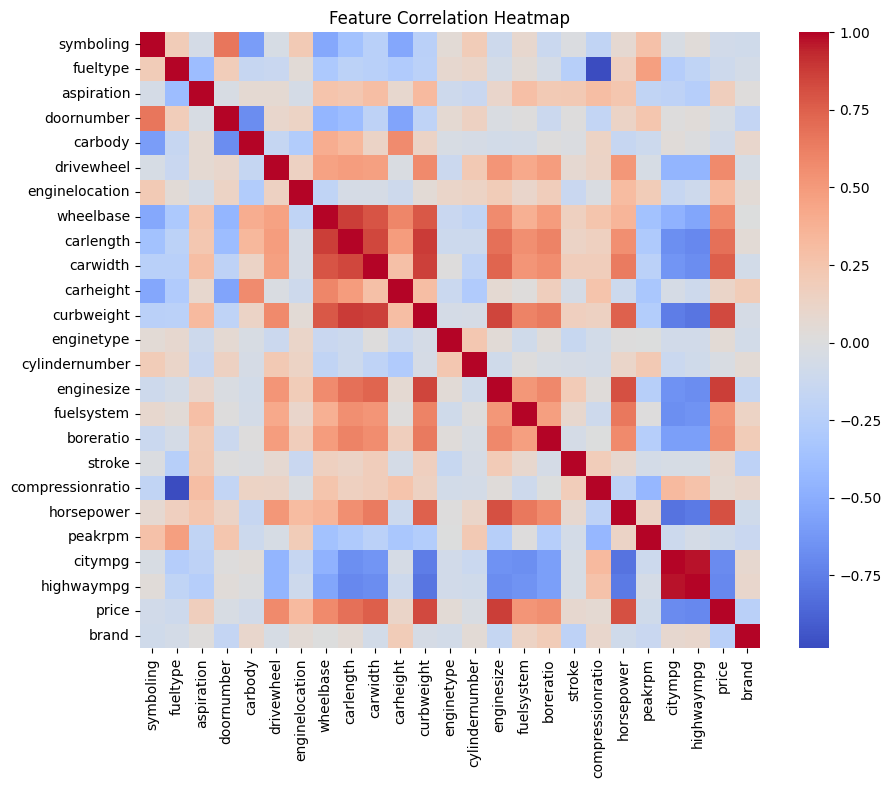

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature Selection

In [64]:
X = df.drop('price', axis=1)
y = df['price']
print(X.shape)
print(y.shape)

(205, 24)
(205,)


## Data Splitting

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(164, 24) (41, 24)


## Feature Scaling

In [66]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train[:5])

[[-0.72738032 -3.15171911 -0.46348119 -0.91798509  0.45721393  1.19131812
  -0.13650473  1.03708546  0.07244984  0.08381686  0.27677891  0.28128677
   0.04963143 -0.16709347  0.18801047 -0.13609459  0.4058361   1.21510088
   3.09986047 -0.81538553 -1.91782869  0.96431609  1.3135007  -0.45585288]
 [-0.72738032  0.31728716 -0.46348119 -0.91798509  0.45721393  1.19131812
  -0.13650473  1.54123134  1.04391556  1.17026768  1.20726917  1.01604452
  -0.85476353 -0.16709347 -0.15899277  0.85588374  0.51738434 -3.36016616
  -0.43959084 -0.24189416 -0.292907   -0.98812636 -1.02456857  0.08198793]
 [-0.72738032  0.31728716 -0.46348119 -0.91798509  1.61079985 -0.63462741
  -0.13650473 -0.50896191 -0.36761583 -1.09710795  2.17821552 -0.54164191
   0.04963143 -0.16709347 -0.85299925 -1.12807291 -1.00710835 -0.70966663
  -0.28343858 -1.0647296  -0.69913742  0.96431609  1.00175813  1.02320934]
 [ 0.07863571  0.31728716 -0.46348119 -0.91798509  0.45721393 -0.63462741
  -0.13650473 -0.71062026 -0.732953

## Model Training

In [67]:
model = LinearRegression()
model.fit(X_train, y_train)
print(model.coef_)
print(model.intercept_)

[  199.29036441  3072.62419563   409.73476405  -733.41350555
  -988.40574606   399.08240925  1530.4637455   1073.34637158
  -598.65883782  1211.28181707   468.383854    1300.27199806
   319.73526539  -193.91103631  3205.93737004   272.76852315
  -226.3287045   -643.27937847  3522.43432598   758.91486771
   641.64618418 -1034.55884019   524.89113551 -1058.17175894]
13223.414634146346


## Prediction

In [68]:
y_pred = model.predict(X_test)
print(y_pred[:5])

[25516.53593792 17676.20792664  9776.21518158 13503.67610117
 26227.13934217]


## Model Evaluation

In [69]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8393406655590523
MAE: 2147.1211874318374
MSE: 12683093.852618087


## Actual vs Predicted

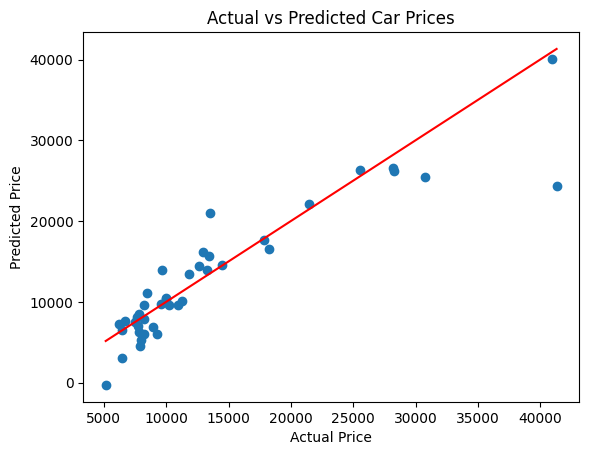

In [70]:
plt.scatter(y_test, y_pred)

# Add perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()